# A Quick Tour of Symbulate

**Symbulate** lets you simulate probability models with syntax that reads like the math. In this tour we'll:

1. Define a distribution and a random variable
2. Read off its theoretical values
3. Simulate it and compare the simulation to the theory
4. Discover a relationship between distributions
5. Simulate a multivariate distribution and view a pairs plot
6. Run a random process (an M/M/1 queue)

Everything starts with a single import.

In [1]:
from symbulate import *

## 1. Distributions and random variables

A **distribution** describes how a random quantity behaves. Wrapping it in `RV(...)` turns it into a **random variable** you can simulate, transform, and combine. Say scores on a test are Normal with mean 100 and standard deviation 15.

In [2]:
X = RV(Normal(mean=100, sd=15))
X.draw()   # one random value

108.80731314811541

## 2. Theoretical values

The distribution knows its own exact mean, standard deviation, percentiles, etc. -- no simulation needed.

In [3]:
Logistic(loc=2, scale=3).mean(), Logistic(loc=2, scale=3).var(), Logistic(loc=2, scale=3).sd()

(np.float64(2.0),
 np.float64(29.608813203268074),
 np.float64(5.441398092702653))

## 3. Simulate, and compare to the theory

`sim(n)` draws `n` independent values. Plotting the simulation and then the true distribution in the same cell overlays them -- the histogram of 10,000 simulated scores lands right on the theoretical bell curve.

In [4]:
X.sim(10000)

0,78.96161325702289
1,104.45749318164307
2,109.18059640597752
3,89.11604116118768
4,117.05527581812777
5,77.96220363057697
6,105.84262320856425
7,99.55208237859243
8,55.07569139542729
...,...
9999,104.05354130207212


Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


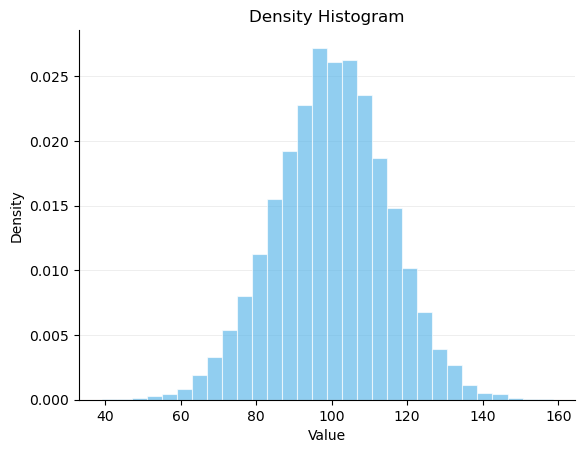

In [5]:
X.sim(10000).plot(suggest=True)

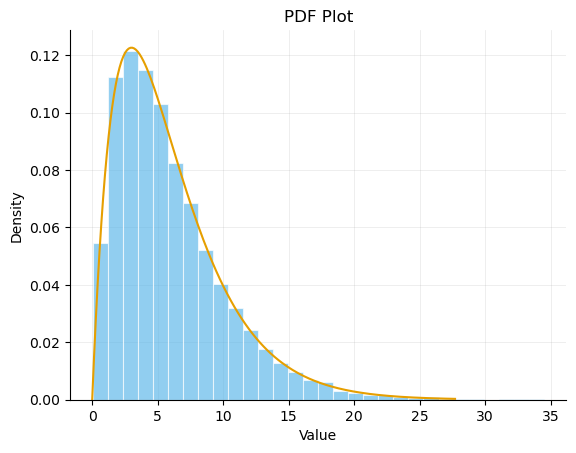

In [6]:
G = RV(Gamma(shape=2, scale=3))
G.sim(10000).plot()          # simulated
Gamma(shape=2, scale=3).plot()   # theoretical

## 4. A relationship between distributions

Random variables can be combined with ordinary arithmetic. A classic result: **the sum of two independent Uniform(0, 1) variables has a triangular distribution** on `[0, 2]`, peaking at 1. Here `Uniform(0, 1) ** 2` makes two independent copies; we unpack them, add, and overlay the theoretical `Triangular`.

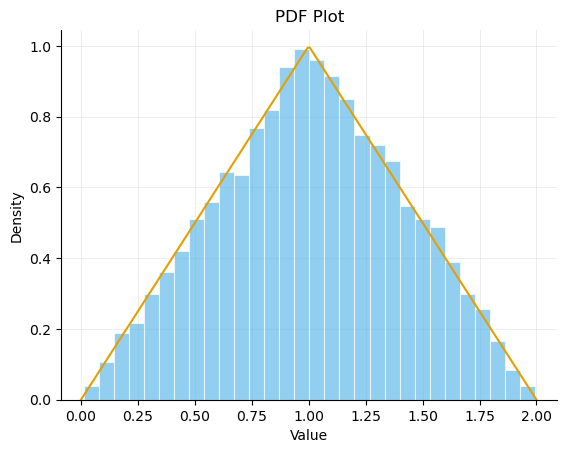

In [7]:
U, V = RV(Uniform(0, 1) ** 2)
(U + V).sim(10000).plot()
Triangular(low=0, mode=1, high=2).plot()

## 5. A multivariate distribution and a pairs plot

A `MultivariateNormal` produces a whole vector of correlated values at once. Plotting them together gives a **pairs plot** -- each component's distribution on the diagonal and every pairwise scatter off it, so the correlations are visible directly.

In [8]:
Vec = RV(
    MultivariateNormal(
        mean=[0, 0, 0],
        cov=[[1, 0.8, 0.3], [0.8, 1, 0.5], [0.3, 0.5, 1]],
    )
)
Vec.draw()

(0.2857527585897076, -1.160416318567993, -1.4795608765969064)

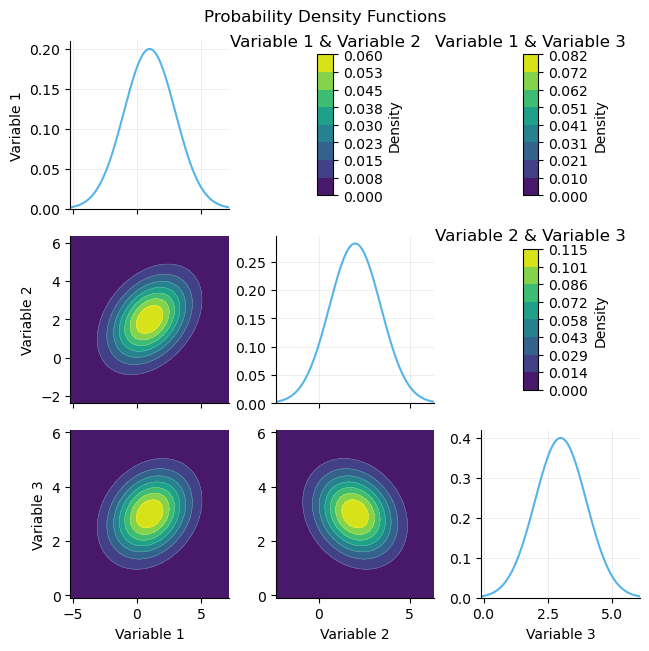

In [9]:
MultivariateNormal(mean=[1, 2, 3],
                   cov=[[4, 1, 0.5], [1, 2, -0.3], [0.5, -0.3, 1]]).plot()

## 6. A random process: the M/M/1 queue

Symbulate also simulates processes that evolve over time. An **M/M/1 queue** has customers arriving at rate 1 and a single server working at rate 1.5. Each draw is a sample path -- the number of customers in the system as time goes on.

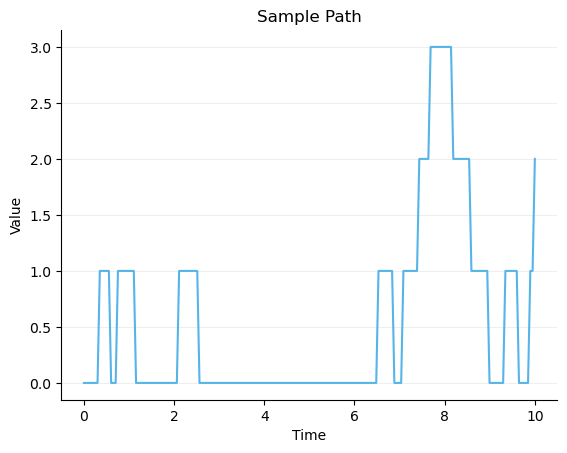

In [10]:
queue = MM1(arrival_rate=1, service_rate=1.5)
queue.draw().plot()

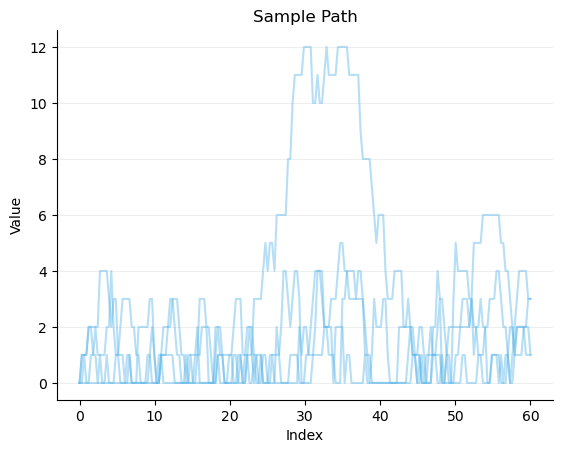

In [11]:
queue = MM1(arrival_rate=1, service_rate=1.5)
queue.sim(4).plot(tmin=0, tmax=60)